In [21]:
import os
import json
import geopandas as gpd
import pandas as pd
from shapely.geometry import box

app_name = "my-app"

In [22]:
def decode_polyline(encoded):
    coords = []
    index = 0
    lat, lng = 0, 0

    while index < len(encoded):
        # Decode latitude
        result, shift = 0, 0
        while True:
            b = ord(encoded[index]) - 63
            index += 1
            result |= (b & 0x1F) << shift
            shift += 5
            if b < 0x20:
                break
        lat += ~(result >> 1) if result & 1 else result >> 1

        # Decode longitude
        result, shift = 0, 0
        while True:
            b = ord(encoded[index]) - 63
            index += 1
            result |= (b & 0x1F) << shift
            shift += 5
            if b < 0x20:
                break
        lng += ~(result >> 1) if result & 1 else result >> 1

        coords.append((lat / 1e5, lng / 1e5))

    return coords

activities = json.load(open("activities.json"))

#only select cycling activities
activities = [activity for activity in activities if activity["type"] == "Ride"]

#get the summary polyline of the first activity
polylines = [activity["map"]["summary_polyline"] for activity in activities]

#decode the polylines into coordinates
all_coords = [decode_polyline(polyline) for polyline in polylines]

all_routes = gpd.GeoDataFrame()

#for each activity, create a LineString geometry from the coordinates and add it to the GeoDataFrame

from shapely.geometry import LineString

for coords in all_coords:
    line = gpd.GeoSeries([LineString([(lon, lat) for lat, lon in coords])])
    all_routes = pd.concat([all_routes, gpd.GeoDataFrame(geometry=line)], ignore_index=True)

all_routes = gpd.GeoDataFrame(all_routes, geometry="geometry")

#delete any rows that are not entirely within the bounding box: (47.96728205520181, -124.06261774909336), (49.80073837001835, -121.82124601966595)

bbox = box(-124.06261774909336, 47.96728205520181, -121.82124601966595, 49.80073837001835)
activities = all_routes[all_routes.within(bbox)]

activities = activities.set_crs(epsg=4326).to_crs(epsg=32610)
        

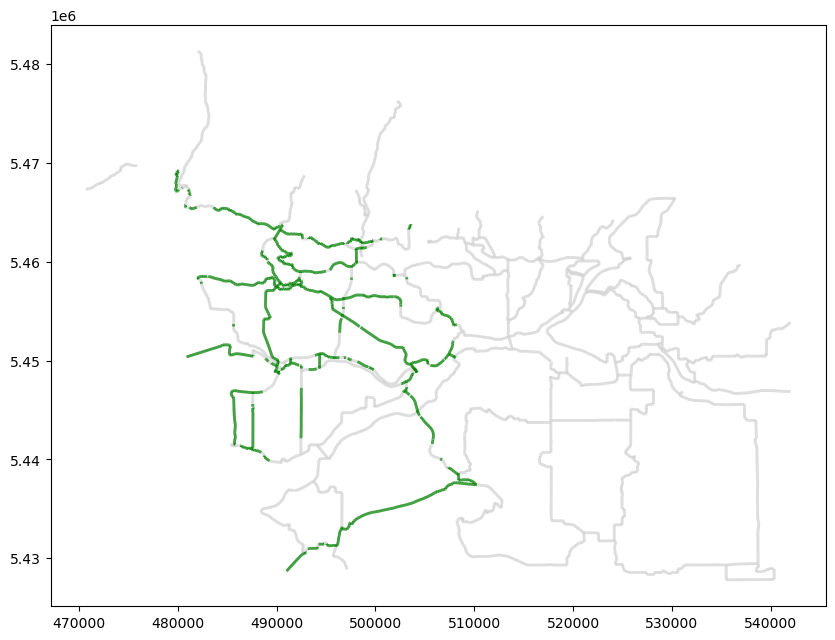

In [ ]:
import random

def split_linestring_into_segments(line, segment_length=50):
    """Split a single LineString into segments of a given length (in metres)."""
    segments = []
    total_length = line.length
    distance = 0

    while distance < total_length:
        start = line.interpolate(distance)
        end = line.interpolate(min(distance + segment_length, total_length))
        segments.append(LineString([start, end]))
        distance += segment_length

    return segments

def split_gdf_into_segments(gdf, segment_length=50):
    rows = []

    for _, row in gdf.iterrows():
        segments = split_linestring_into_segments(row.geometry, segment_length)
        for segment in segments:
            color = "#{:06x}".format(random.randint(0, 0xFFFFFF))
            new_row = row.copy()
            new_row.geometry = segment
            new_row["color"] = color
            rows.append(new_row)

    return gpd.GeoDataFrame(rows, crs=gdf.crs)

for network_name in os.listdir("networks"):
    if network_name.endswith(".geojson"):
        gdf = gpd.read_file(os.path.join("networks", network_name))
        
        #convert to utm zone 10n
        gdf = gdf.set_crs(epsg=4326).to_crs(epsg=32610)

        #split into segments of N length
        network = split_gdf_into_segments(gdf, segment_length=50)
        activities_simplified = activities.copy()
        activities_simplified.geometry = activities.geometry.simplify(1)

        from scipy.spatial import cKDTree
        import numpy as np

        def find_visited_segments(activities, network, buffer_distance=50):
            # Sample points along all activity lines
            activity_points = []
            for geom in activities.geometry:
                distances = np.arange(0, geom.length, 5)  # sample every 5m
                activity_points.extend([geom.interpolate(d) for d in distances])
            
            coords = np.array([(p.x, p.y) for p in activity_points])
            tree = cKDTree(coords)

            # Get midpoint of each network segment and query the tree
            midpoints = np.array([(geom.interpolate(0.5, normalized=True).x, 
                                geom.interpolate(0.5, normalized=True).y) 
                                for geom in network.geometry])
            
            distances, _ = tree.query(midpoints, k=1)
            network["visited"] = distances <= buffer_distance

            return network

        network = find_visited_segments(activities_simplified, network, buffer_distance=50)

        #plot network and activities together
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 10))
        
        #plot network segments, coloring visited segments in green and unvisited segments in grey
        network.loc[~network["visited"]].plot(ax=ax, color="lightgrey", linewidth=2)
        network.loc[network["visited"]].plot(ax=ax, color="green", linewidth=2)
    
        network = network.to_crs(epsg=4326)
        network = network[['visited', 'geometry']]

        #export to geojson
        network.to_file(app_name + "/public/geojson/" + network_name, driver="GeoJSON")
    
    activities = activities.to_crs(epsg=4326)
    activities = activities[['geometry']]
    activities.to_file(app_name + "/public/geojson/" + "activities.geojson", driver="GeoJSON")